In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import mult_grad_population_calibration.optimize_weights as opt
import mult_grad_population_calibration.utils as utils


### Set up directories for loading and saving, and set up plotting info

In [2]:
# Set up directories
main_dir = ".."
fig_dir = f"{main_dir}/figures/hsp90"
data_dir = f"{main_dir}/data/"

# Set up pretty plots 
plt.style.use(f"{main_dir}/my_style.mplstyle") # Use stylefile defined
plt.style.use("seaborn-v0_8-colorblind") # Use colorscheme from colorblind seaborn

### Load in pre-computed likelihood matrix
The log-likelihood matrix is a matrix $L$ where $$L_{ij} = \log p(y_i| x_j)$$ for an image $y_i$ and a conformation $x_j.$ This can be computed a variety of ways in cryo-EM, and depends both on what imaging forward model is used as well as how poses are treated.

The log-likelihood matrix comes from a dataset of images $\{y_i\}_{i=1}^N$ and conformations  $\{x_j\}_{j=1}^M,$ which we don't have to load explicitly.
The matrix is size $N \times M,$ where each row corresponds to an image, and each column corresponds to a conformation.

In [3]:
# Load likelihood matrix
log_likelihood = jnp.load(f"{data_dir}/likelihoods/hsp90/log_likelihood_cryojax_low_snr.npy")
num_data, num_nodes = jnp.shape(log_likelihood)
print("Loaded log likelihood matrix.")
print(f"number of images: {num_data}")
print(f"number of conformations: {num_nodes}")

Loaded log likelihood matrix.
number of images: 100000
number of conformations: 20


### TODO: markdown cell showing visual of the given example. e.g: for uploaded likelihood matrix, image of some of the conformations, and some of the images.

### Plot "true weights"
Since this is a synthetic example, we have access to the true set of weights $\{\pi_j\}_{j=1}^M$ that images were generated from, and we can later in this notebook track the error of our estimated weights to the true ones.  

For this example, the weights are from evaluating a 1D mixture of Gaussians equi-spaced nodes. The weights for this problem can be indexed in 1D, where weights with nearby index correspond to nearby structures, because the motion in the conformations $\{x_j\}_{j=1}^M$ can be parametrized by a 1D parameter, a dihedral angle between the two "arms" of hsp90. 


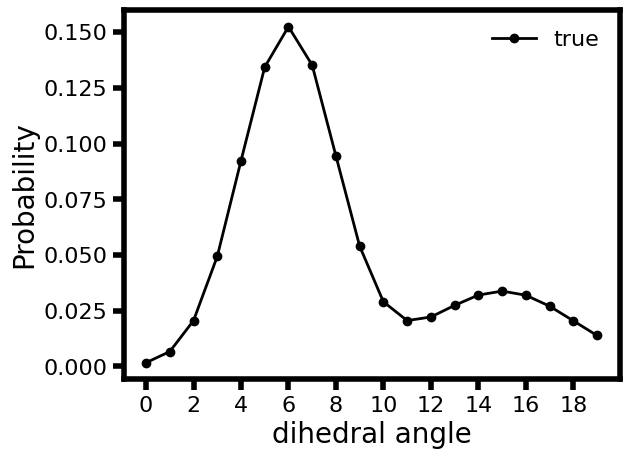

In [4]:
nodes = jnp.arange(0, num_nodes, 1)
weights_true = jnp.load(f"{data_dir}/hsp90_true_weights.npy")
# normalize output to integrate to 1 on the grid 
plt.plot(nodes, weights_true, label='true', color="k", marker='.', markersize=12)
plt.xticks(jnp.arange(0, 20, 2))
plt.xlabel('dihedral angle')
plt.ylabel('Probability')  
plt.legend()

### Compute multiplicative gradient weights with default criteria, then plot.

In our plots, we are using a default function in `utils.py` to show:
- a plot of the optimized weights against the true weights
- loss versus iterations. Here, loss is the negative marginal log likelihood of the data, given the weights.
- gap versus iterations. Here, the "gap" is an approximation to the loss difference between our weights at step t, and the *maximum likelihood weights* (not necessarily the ground truth weights).

In [5]:
# Compute weights
weights, info = opt.multiplicative_gradient(log_likelihood)

NOTE: Plotting with initial loss and gap at iterations=0
Iterations are shifted to start at iterations=1, to do a log-plot on x-axis
To see trends easier, you may want to drop the 0th iteration. To do this, set plot_initial=False


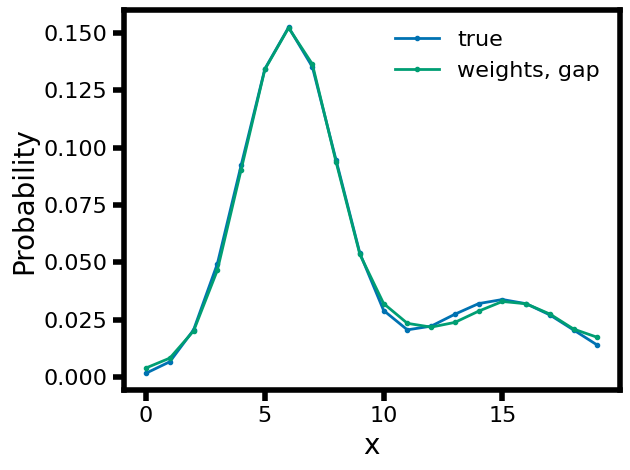

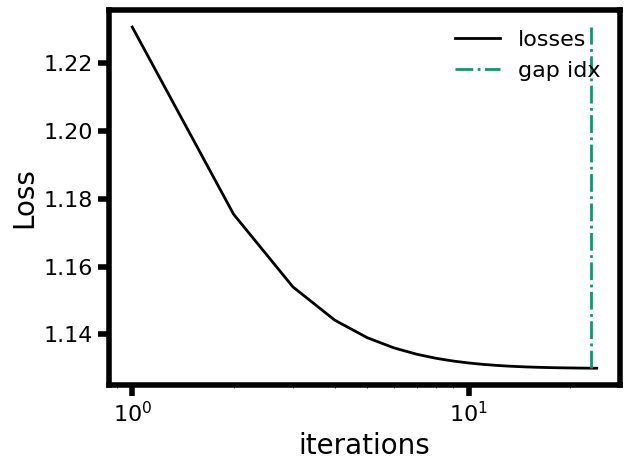

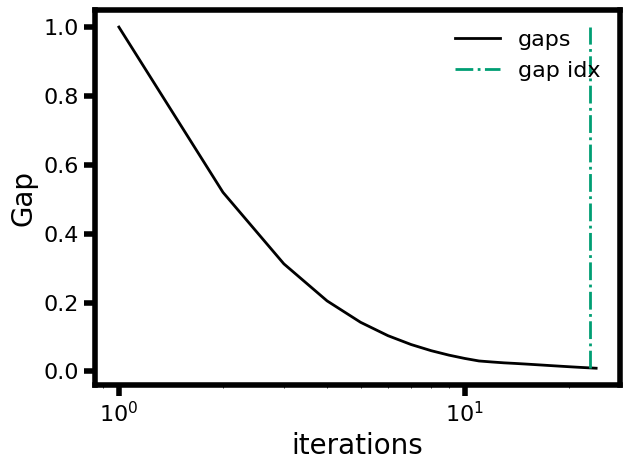

In [6]:
# Plot 
# if wanting to see trends easier, set plot_initial=False, 
# it drops first iterate (initial weights) from plotting x-axis
plot_initial=True
utils.plot_weights_and_info_1d(nodes, 
                               info, 
                               true_weights=weights_true, 
                               plot_initial=plot_initial)
   

### Full diagnostic
We have just so happened to use an example that is very well behaved at default settings. 
In general, this isn't the case, and we may want to iterate for a large set of iterations, and compare weights at different stopping criteria.

Here, we will do this with a parameter setting `diagnostic=True`, and other settings to try other stopping criteria.

In [7]:
# get key for train_test stopping method
# NOTE: TBD, the default train_test is not very robust to this seed, may want to try different values! 
# e.g: setting seed at 0 stops at a very different iteration
seed = 100
key = jax.random.key(seed)

# run to max iterations, compute gap and train_test stopping criteria
weights_final, info = opt.multiplicative_gradient(log_likelihood, 
                                            max_iterations=50000, 
                                            weights_frequency=1,
                                            tol=1e-2, 
                                            train_test_key=key, 
                                            train_test=True,
                                            verbose=True, 
                                            diagnostic=True)

losses = info["losses"]
gaps = info["gaps"]
weights_gap = info["weights_gap"]
weights_train_test = info["weights_train_test"]
train_test_idx = info["train_test_idx"] 
weights_history = info["weights_history"]
gap_idx = info["gap_idx"]


Getting train test stopping index
Validation loss increases at idx: 48
reached gap tolerance, at idx: 23
gap: 0.0094703808426857


### here, we will also plot the divergence from true weights to iterated weights

`weights_history` is a `num_nodes` X `num_iteration % weights_frequency` array, that contains the weights from every `weights_frequency` iterations.

to compute these divergences, we will loop through here, compute the divergences and store.

In [8]:
@jax.jit
def kl_div(x, y):
    return jnp.sum(jax.scipy.special.rel_entr(x, y))

divergences = []
for i in range(len(weights_history)):
    weights_current = weights_history[i, :]
    divergences.append(kl_div(weights_current, weights_true))
divergences = jnp.stack(jnp.array(divergences))

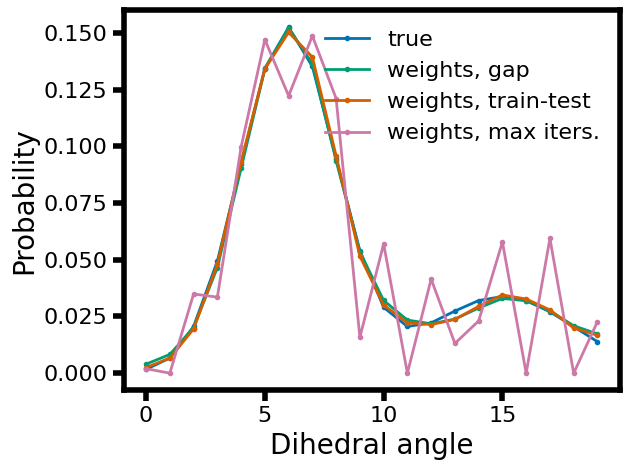

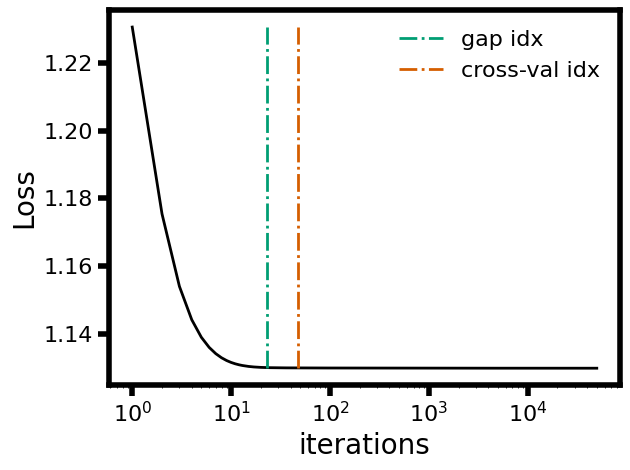

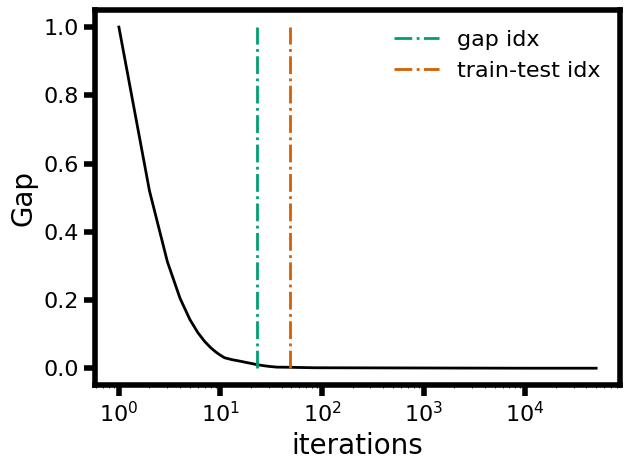

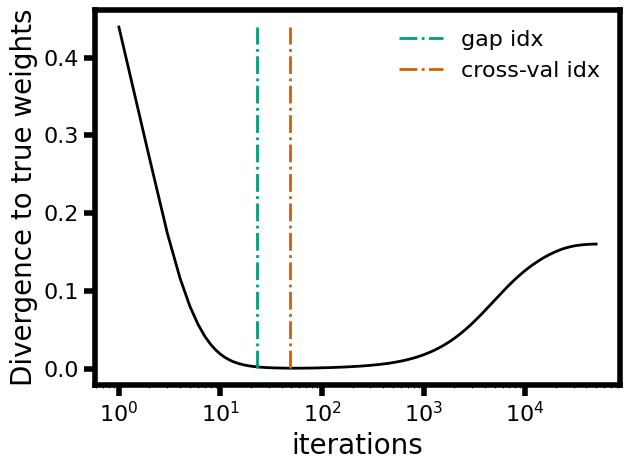

In [9]:
iterations = jnp.arange(0, len(losses), 1) + 1
# Plot final weights
plt.figure()
plt.plot(nodes, weights_true, label='true', color="C0", marker='.')
plt.plot(nodes, weights_gap, label='weights, gap', color="C1", marker='.')
plt.plot(nodes, weights_train_test, label='weights, train-test', color="C2", marker='.')
plt.plot(nodes, weights_final, label='weights, max iters.', color="C3", marker='.')
plt.xlabel('Dihedral angle')
plt.ylabel('Probability') 
plt.legend(loc="upper right", fontsize=16)
plt.tight_layout()
if fig_dir is not None:
    plt.savefig(f"{fig_dir}/weight_comparison.png", dpi=300)

# Plot losses
plt.figure()
plt.semilogx(iterations, losses, c='k')
plt.vlines(gap_idx, ymin=jnp.min(losses), ymax=jnp.max(losses), colors='C1', linestyles="-.", label="gap idx")
plt.vlines(train_test_idx, ymin=jnp.min(losses), ymax=jnp.max(losses), colors='C2', linestyles="-.", label="cross-val idx")
plt.xlabel('iterations')
plt.ylabel('Loss') 
plt.legend(fontsize=16)
plt.tight_layout()

# Plot gaps
plt.figure()
# Here plotting a semilog plot, and shifting indices so 0 doesn't show up
plt.semilogx(iterations, gaps, c='k')
plt.vlines(gap_idx, ymin=jnp.min(gaps), ymax=jnp.max(gaps), colors='C1', linestyles="-.", label="gap idx")
plt.vlines(train_test_idx, ymin=jnp.min(gaps), ymax=jnp.max(gaps), colors='C2', linestyles="-.", label="train-test idx")
plt.xlabel('iterations')
plt.ylabel('Gap') 
plt.legend(fontsize=16)
plt.tight_layout()


# Plot divergences to true weights
plt.figure()
plt.semilogx(iterations, divergences, c='k')
plt.vlines(gap_idx, ymin=jnp.min(divergences), ymax=jnp.max(divergences), colors='C1', linestyles="-.", label="gap idx")
plt.vlines(train_test_idx, ymin=jnp.min(divergences), ymax=jnp.max(divergences), colors='C2', linestyles="-.", label="cross-val idx")
plt.xlabel('iterations')
plt.ylabel('Divergence to true weights') 
plt.legend(fontsize=16)
plt.tight_layout()

### Plots for a range of stopping criteria

Below is rudimentary code for finding the indices of stopping criteria between a minimum and maximum value of the "gap" criteria.
After that, plotting the range on plots from earlier.

In [23]:
max_tol = 1e-1
min_tol = 1e-4
min_check = True
i = 0
gap_val = gaps[0]
while gap_val > max_tol:
    gap_val = gaps[i]
    i += 1
max_gap_idx = i
while gap_val > min_tol:
    gap_val = gaps[i]
    i +=1
min_gap_idx = i

print(max_gap_idx)
print(min_gap_idx)


7
5819


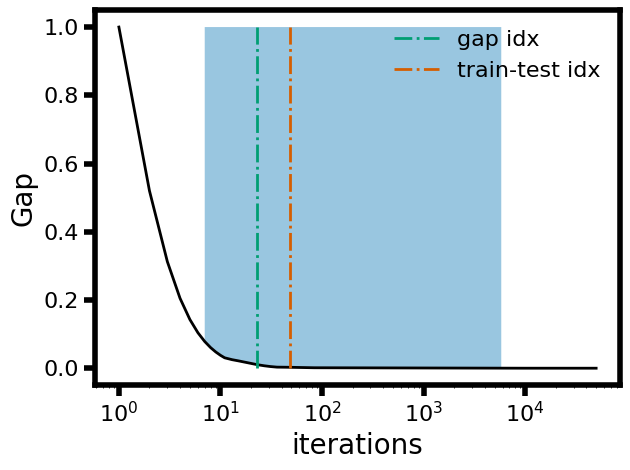

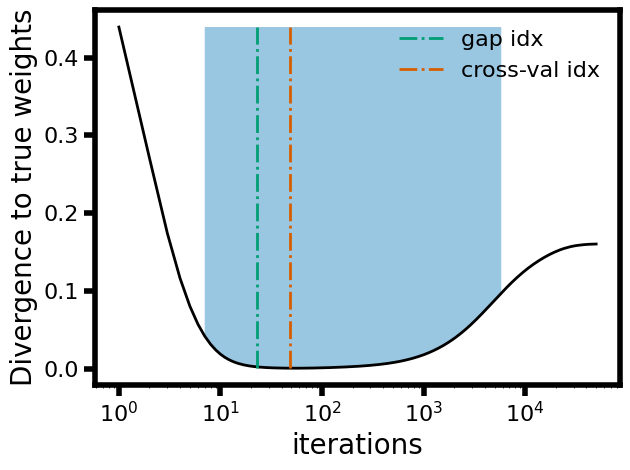

In [24]:
# Plot gaps
plt.figure()
# Here plotting a semilog plot, and shifting indices so 0 doesn't show up
plt.semilogx(iterations, gaps, c='k')
plt.vlines(gap_idx, ymin=jnp.min(gaps), ymax=jnp.max(gaps), colors='C1', linestyles="-.", label="gap idx")
plt.vlines(train_test_idx, ymin=jnp.min(gaps), ymax=jnp.max(gaps), colors='C2', linestyles="-.", label="train-test idx")
plt.fill_between(iterations, gaps, jnp.max(gaps), where=(iterations>=max_gap_idx) & (iterations<=min_gap_idx), alpha=0.4) 
plt.xlabel('iterations')
plt.ylabel('Gap') 
plt.legend(fontsize=16, loc="upper right")
plt.tight_layout()

# Plot divergences to true weights
plt.figure()
plt.semilogx(iterations, divergences, c='k')
plt.vlines(gap_idx, ymin=jnp.min(divergences), ymax=jnp.max(divergences), colors='C1', linestyles="-.", label="gap idx")
plt.vlines(train_test_idx, ymin=jnp.min(divergences), ymax=jnp.max(divergences), colors='C2', linestyles="-.", label="cross-val idx")
plt.fill_between(iterations, divergences, jnp.max(divergences), where=(iterations>=max_gap_idx) & (iterations<=min_gap_idx), alpha=0.4) 
plt.xlabel('iterations')
plt.ylabel('Divergence to true weights') 
plt.legend(fontsize=16, loc="upper right")
plt.tight_layout()